In [ ]:
import numpy as np
import joblib
import xgboost as xgb
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROCESSED = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\data\processed"
RESULTS   = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\results"
MODELS    = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\models"

X_train = np.load(os.path.join(PROCESSED, "ciciomt2024_X_train.npy"))
X_val   = np.load(os.path.join(PROCESSED, "ciciomt2024_X_val.npy"))
X_test  = np.load(os.path.join(PROCESSED, "ciciomt2024_X_test.npy"))
y_train = np.load(os.path.join(PROCESSED, "ciciomt2024_y_train.npy"))
y_val   = np.load(os.path.join(PROCESSED, "ciciomt2024_y_val.npy"))
y_test  = np.load(os.path.join(PROCESSED, "ciciomt2024_y_test.npy"))
class_weights = joblib.load(os.path.join(PROCESSED, "ciciomt2024_class_weights.pkl"))

scale_pos_weight = class_weights[0] / class_weights[1]
print(f"Train: {X_train.shape}")
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

# ── Train ─────────────────────────────────────────────────────────────────
print("\nTraining XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=6,
    scale_pos_weight=scale_pos_weight, random_state=42,
    eval_metric='logloss', early_stopping_rounds=10, n_jobs=-1)

xgb_model.fit(X_train, y_train,
    eval_set=[(X_val, y_val)], verbose=50)
print("Done.")

# ── Evaluate ──────────────────────────────────────────────────────────────
def evaluate(model, X, y, name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    print(f"\n{name}:")
    print(f"  F1:        {f1_score(y, y_pred):.4f}")
    print(f"  AUC-ROC:   {roc_auc_score(y, y_prob):.4f}")
    print(f"  Precision: {precision_score(y, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y, y_pred):.4f}")
    print(f"  Accuracy:  {accuracy_score(y, y_pred):.4f}")

evaluate(xgb_model, X_val,  y_val,  "Validation")
evaluate(xgb_model, X_test, y_test, "Test")

# ── Confusion Matrix ──────────────────────────────────────────────────────
y_pred_test = xgb_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title('XGBoost — CICIoMT-2024', fontsize=12)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciomt2024_xgboost_confusion_matrix.png"), dpi=150)
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"\nTN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")

# ── Save ──────────────────────────────────────────────────────────────────
xgb_model.save_model(os.path.join(MODELS, "ciciomt2024_xgboost.json"))
print("Model saved.")

Train: (350000, 38)
scale_pos_weight: 36.1274

Training XGBoost...
[0]	validation_0-logloss:0.15399
[50]	validation_0-logloss:0.00873
[100]	validation_0-logloss:0.00639
[150]	validation_0-logloss:0.00527
[199]	validation_0-logloss:0.00444
Done.

Validation:
  F1:        0.9990
  AUC-ROC:   1.0000
  Precision: 0.9982
  Recall:    0.9998
  Accuracy:  0.9981

Test:
  F1:        0.9991
  AUC-ROC:   1.0000
  Precision: 0.9983
  Recall:    0.9999
  Accuracy:  0.9983


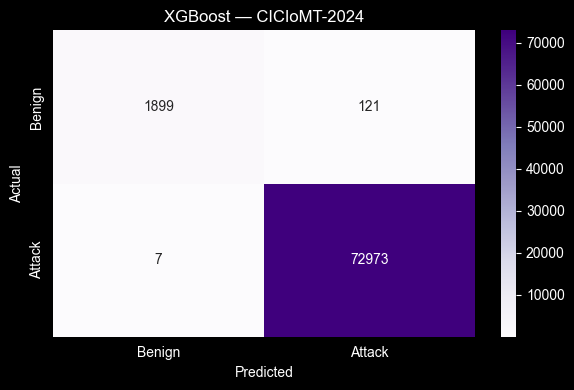


TN: 1899  FP: 121  FN: 7  TP: 72973
Model saved.


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# DAY 14 SUMMARY — XGBoost on CICIoMT-2024
# ══════════════════════════════════════════════════════════════════════════
#
# MODEL: XGBoost (Gradient Boosting)
# Config: 200 estimators, lr=0.1, max_depth=6, scale_pos_weight applied
#
# RESULTS:
#   F1:        0.9991
#   AUC-ROC:   1.0000  ← perfect discrimination
#   Precision: 0.9983
#   Recall:    0.9999
#   Accuracy:  0.9983
#
# KEY OBSERVATION:
#   AUC-ROC of 1.0000 — XGBoost perfectly separates benign from attack
#   in this dataset. Near-perfect recall (0.9999) means virtually zero
#   missed attacks. CICIoMT-2024 medical IoT attacks are extremely
#   distinct in feature space.
#
# CROSS-DATASET COMPARISON (XGBoost):
#   CIC-IoT-2023:  F1=0.9805  AUC=0.9958
#   CICIoMT-2024:  F1=0.9991  AUC=1.0000  ← +0.0186 F1 improvement
# ══════════════════════════════════════════════════════════════════════════